# Análisis Exploratorio de Netflix (EDA)
En este proyecto exploro el catálogo de Netflix para entender la distribución de películas y series, 
tendencias por año de lanzamiento, géneros más comunes y participación de distintos países. 
Este análisis es 100% exploratorio (EDA) y muestra mi capacidad para manipular datos y generar visualizaciones.


1-¿Qué proporción hay entre películas y series en Netflix?

2-¿Cómo evolucionó la cantidad de estrenos a lo largo de los años?

3-¿Qué países aportan más títulos al catálogo?

4-¿Cuáles son los géneros (categorías) más frecuentes?

5-¿Cuál es la distribución de las duraciones (ej. minutos en películas, temporadas en series)?

In [13]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)



In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Cargar dataset
df = pd.read_csv("netflix.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [15]:
print("Filas y columnas:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())


Filas y columnas: (8807, 12)

Tipos de datos:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Valores nulos por columna:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


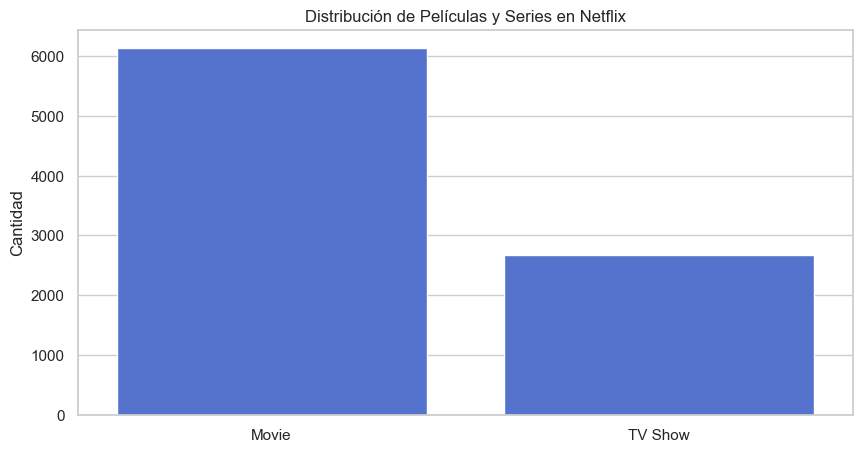

In [16]:
sns.countplot(data=df, x="type", color="royalblue")
plt.title("Distribución de Películas y Series en Netflix")
plt.xlabel("")
plt.ylabel("Cantidad")
plt.show()


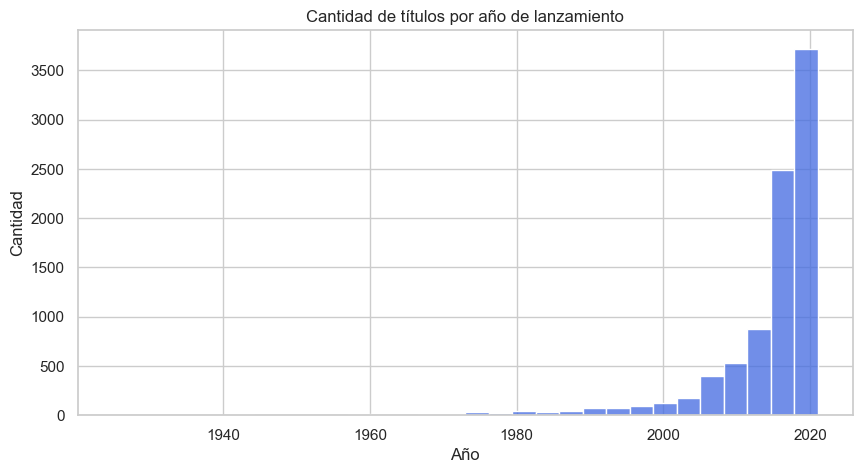

In [17]:
sns.histplot(df["release_year"], bins=30, kde=False, color="royalblue")
plt.title("Cantidad de títulos por año de lanzamiento")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.show()


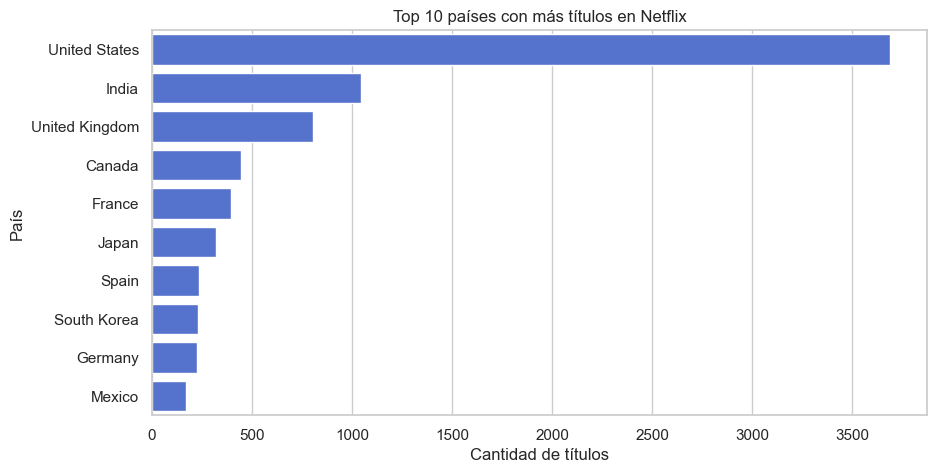

In [18]:
top_countries = df["country"].dropna().str.split(", ").explode().value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, color="royalblue")
plt.title("Top 10 países con más títulos en Netflix")
plt.xlabel("Cantidad de títulos")
plt.ylabel("País")
plt.show()


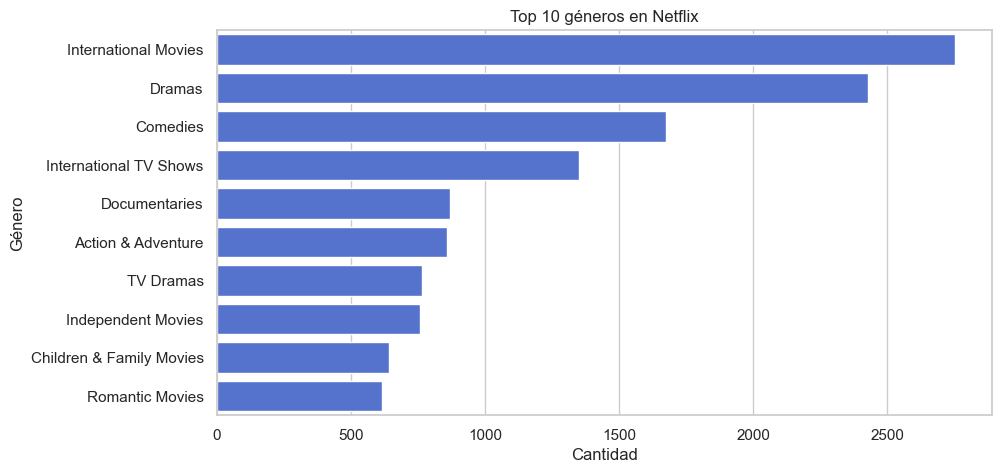

In [19]:
genres = (
    df["listed_in"].dropna().str.split(", ").explode().value_counts().head(10)
    .rename_axis("Género").reset_index(name="Cantidad")
)

sns.barplot(x="Cantidad", y="Género", data=genres, color="royalblue")
plt.title("Top 10 géneros en Netflix")
plt.xlabel("Cantidad")
plt.ylabel("Género")
plt.show()


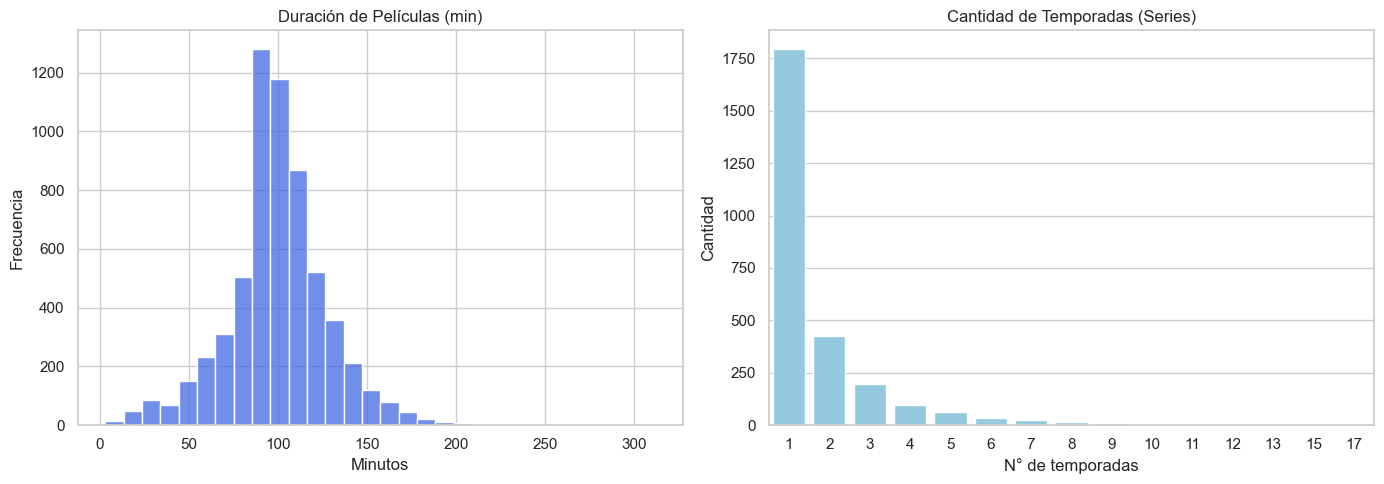

In [20]:
# Crear copias explícitas para evitar SettingWithCopyWarning
movies = df.loc[df["type"] == "Movie"].copy()
shows  = df.loc[df["type"] == "TV Show"].copy()

# Extraer números
movies["minutes"] = pd.to_numeric(movies["duration"].str.extract(r"(\d+)")[0], errors="coerce")
shows["seasons"]  = pd.to_numeric(shows["duration"].str.extract(r"(\d+)")[0], errors="coerce")

# Gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(movies["minutes"].dropna(), bins=30, ax=axes[0], color="royalblue")
axes[0].set_title("Duración de Películas (min)")
axes[0].set_xlabel("Minutos")
axes[0].set_ylabel("Frecuencia")

order = sorted(shows["seasons"].dropna().unique())
sns.countplot(x=shows["seasons"], ax=axes[1], color="skyblue", order=order)
axes[1].set_title("Cantidad de Temporadas (Series)")
axes[1].set_xlabel("N° de temporadas")
axes[1].set_ylabel("Cantidad")

plt.tight_layout()
plt.show()
